In [2]:
# Imports and paths

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Reproducibility
np.random.seed(42)

# Project paths
PROJECT_DIR = Path.cwd().parent
DATA_DIR = PROJECT_DIR / "data"
OUTPUTS_DIR = PROJECT_DIR / "outputs"

DATA_DIR.mkdir(exist_ok=True)
OUTPUTS_DIR.mkdir(exist_ok=True)

print("Project directory:", PROJECT_DIR)
print("Data directory:", DATA_DIR)

Project directory: D:\aws-kpi-anomaly-detection
Data directory: D:\aws-kpi-anomaly-detection\data


In [4]:
# Dataset configuration
num_cells = 8
num_days = 60
freq = "1H"  # hourly KPI samples

start_date = "2026-01-01"
timestamps = pd.date_range(start=start_date, periods=num_days * 24, freq=freq)

cell_ids = [f"CELL_{i:03d}" for i in range(1, num_cells + 1)]

print("Number of cells:", len(cell_ids))
print("Number of timestamps per cell:", len(timestamps))
print("Expected total rows:", len(cell_ids) * len(timestamps))

Number of cells: 8
Number of timestamps per cell: 1440
Expected total rows: 11520


In [6]:
# Generate normal KPI behavior. This function creates normal network behavior.

def generate_normal_kpis(cell_id, timestamps):
    """
    Generate realistic telecom KPI behavior for one cell.
    The data includes daily traffic pattern, weekend effect, and random noise.
    """
    
    df = pd.DataFrame({
        "timestamp": timestamps,
        "cell_id": cell_id
    })
    
    # Time features
    df["hour"] = df["timestamp"].dt.hour
    df["day_of_week"] = df["timestamp"].dt.dayofweek
    df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)
    
    # Daily load pattern: higher during daytime/evening, lower at night
    daily_pattern = 0.5 + 0.5 * np.sin((df["hour"] - 6) / 24 * 2 * np.pi)
    daily_pattern = np.clip(daily_pattern, 0, 1)
    
    # Weekend traffic slightly lower
    weekend_factor = np.where(df["is_weekend"] == 1, 0.85, 1.0)
    
    # Cell-specific behavior
    cell_load_bias = np.random.uniform(-0.08, 0.08)
    cell_quality_bias = np.random.uniform(-0.5, 0.5)
    
    load = np.clip(daily_pattern * weekend_factor + cell_load_bias + np.random.normal(0, 0.05, len(df)), 0, 1)
    
    # KPI generation
    df["prb_utilization"] = 25 + 55 * load + np.random.normal(0, 4, len(df))
    df["throughput_mbps"] = 85 - 45 * load + np.random.normal(0, 5, len(df))
    df["latency_ms"] = 20 + 30 * load + np.random.normal(0, 3, len(df))
    
    df["rrc_setup_success_rate"] = 99.2 - 1.2 * load + cell_quality_bias + np.random.normal(0, 0.25, len(df))
    df["handover_success_rate"] = 98.5 - 1.8 * load + cell_quality_bias + np.random.normal(0, 0.35, len(df))
    df["call_drop_rate"] = 0.3 + 1.2 * load - 0.2 * cell_quality_bias + np.random.normal(0, 0.15, len(df))
    
    # Keep KPIs in realistic ranges
    df["prb_utilization"] = df["prb_utilization"].clip(0, 100)
    df["throughput_mbps"] = df["throughput_mbps"].clip(1, 150)
    df["latency_ms"] = df["latency_ms"].clip(5, 200)
    df["rrc_setup_success_rate"] = df["rrc_setup_success_rate"].clip(80, 100)
    df["handover_success_rate"] = df["handover_success_rate"].clip(75, 100)
    df["call_drop_rate"] = df["call_drop_rate"].clip(0, 20)
    
    # Initial labels
    df["anomaly_label"] = 0
    df["anomaly_type"] = "normal"
    
    return df

In [8]:
# Inject anomalies. This injects events like congestion, handover degradation, RRC degradation, and throughput drops.

def inject_anomalies(df, num_events=5):
    """
    Inject realistic telecom anomaly events into one cell's KPI time series.
    Each anomaly lasts for a few hours.
    """
    
    df = df.copy()
    anomaly_types = [
        "congestion",
        "handover_degradation",
        "rrc_degradation",
        "throughput_drop"
    ]
    
    possible_start_indices = np.arange(24, len(df) - 24)
    
    for _ in range(num_events):
        anomaly_type = np.random.choice(anomaly_types)
        start_idx = np.random.choice(possible_start_indices)
        duration = np.random.randint(3, 10)  # anomaly lasts 3 to 9 hours
        end_idx = min(start_idx + duration, len(df))
        
        idx = df.index[start_idx:end_idx]
        
        if anomaly_type == "congestion":
            df.loc[idx, "prb_utilization"] += np.random.uniform(20, 35)
            df.loc[idx, "throughput_mbps"] *= np.random.uniform(0.45, 0.70)
            df.loc[idx, "latency_ms"] += np.random.uniform(20, 45)
            df.loc[idx, "call_drop_rate"] += np.random.uniform(1.5, 3.5)
            
        elif anomaly_type == "handover_degradation":
            df.loc[idx, "handover_success_rate"] -= np.random.uniform(5, 12)
            df.loc[idx, "call_drop_rate"] += np.random.uniform(1.0, 2.5)
            df.loc[idx, "latency_ms"] += np.random.uniform(5, 15)
            
        elif anomaly_type == "rrc_degradation":
            df.loc[idx, "rrc_setup_success_rate"] -= np.random.uniform(4, 10)
            df.loc[idx, "call_drop_rate"] += np.random.uniform(0.8, 2.0)
            
        elif anomaly_type == "throughput_drop":
            df.loc[idx, "throughput_mbps"] *= np.random.uniform(0.35, 0.60)
            df.loc[idx, "latency_ms"] += np.random.uniform(10, 25)
        
        df.loc[idx, "anomaly_label"] = 1
        df.loc[idx, "anomaly_type"] = anomaly_type
    
    # Clip again after anomalies
    df["prb_utilization"] = df["prb_utilization"].clip(0, 100)
    df["throughput_mbps"] = df["throughput_mbps"].clip(1, 150)
    df["latency_ms"] = df["latency_ms"].clip(5, 250)
    df["rrc_setup_success_rate"] = df["rrc_setup_success_rate"].clip(50, 100)
    df["handover_success_rate"] = df["handover_success_rate"].clip(50, 100)
    df["call_drop_rate"] = df["call_drop_rate"].clip(0, 30)
    
    return df

In [10]:
# Generate full dataset

all_cells = []

for cell_id in cell_ids:
    cell_df = generate_normal_kpis(cell_id, timestamps)
    cell_df = inject_anomalies(cell_df, num_events=6)
    all_cells.append(cell_df)

kpi_df = pd.concat(all_cells, ignore_index=True)

# Reorder columns
columns_order = [
    "timestamp",
    "cell_id",
    "rrc_setup_success_rate",
    "handover_success_rate",
    "call_drop_rate",
    "throughput_mbps",
    "prb_utilization",
    "latency_ms",
    "hour",
    "day_of_week",
    "is_weekend",
    "anomaly_label",
    "anomaly_type"
]

kpi_df = kpi_df[columns_order]

print("Dataset shape:", kpi_df.shape)
kpi_df.head()

Dataset shape: (11520, 13)


,timestamp,cell_id,rrc_setup_success_rate,handover_success_rate,call_drop_rate,throughput_mbps,prb_utilization,latency_ms,hour,day_of_week,is_weekend,anomaly_label,anomaly_type
0,2026-01-01 00:00:00,CELL_001,99.390610,99.213203,0.396134,81.411686,26.401183,24.030174,0,3,0,0,normal
1,2026-01-01 01:00:00,CELL_001,99.211772,98.523758,0.325324,83.998258,23.833997,18.963413,1,3,0,0,normal
2,2026-01-01 02:00:00,CELL_001,99.635269,98.277058,0.289934,69.678204,28.535084,18.768624,2,3,0,0,normal
3,2026-01-01 03:00:00,CELL_001,99.433403,98.799203,0.051910,77.341371,28.701212,26.548894,3,3,0,0,normal
4,2026-01-01 04:00:00,CELL_001,99.436659,98.493148,0.250085,68.468843,39.874322,27.480007,4,3,0,0,normal


In [12]:
# Check anomaly distribution. A realistic dataset should have far more normal points than anomaly points.

print("Anomaly label distribution:")
print(kpi_df["anomaly_label"].value_counts())

print("\nAnomaly percentage:")
print(kpi_df["anomaly_label"].value_counts(normalize=True) * 100)

print("\nAnomaly type distribution:")
print(kpi_df["anomaly_type"].value_counts())

Anomaly label distribution:
0    11218
1      302
Name: anomaly_label, dtype: int64

Anomaly percentage:
0    97.378472
1     2.621528
Name: anomaly_label, dtype: float64

Anomaly type distribution:
normal                  11218
throughput_drop            80
handover_degradation       79
congestion                 77
rrc_degradation            66
Name: anomaly_type, dtype: int64


In [14]:
# Save dataset to CSV

csv_path = DATA_DIR / "synthetic_telecom_kpi_data.csv"

kpi_df.to_csv(csv_path, index=False)

print(f"Dataset saved to: {csv_path}")

Dataset saved to: D:\aws-kpi-anomaly-detection\data\synthetic_telecom_kpi_data.csv


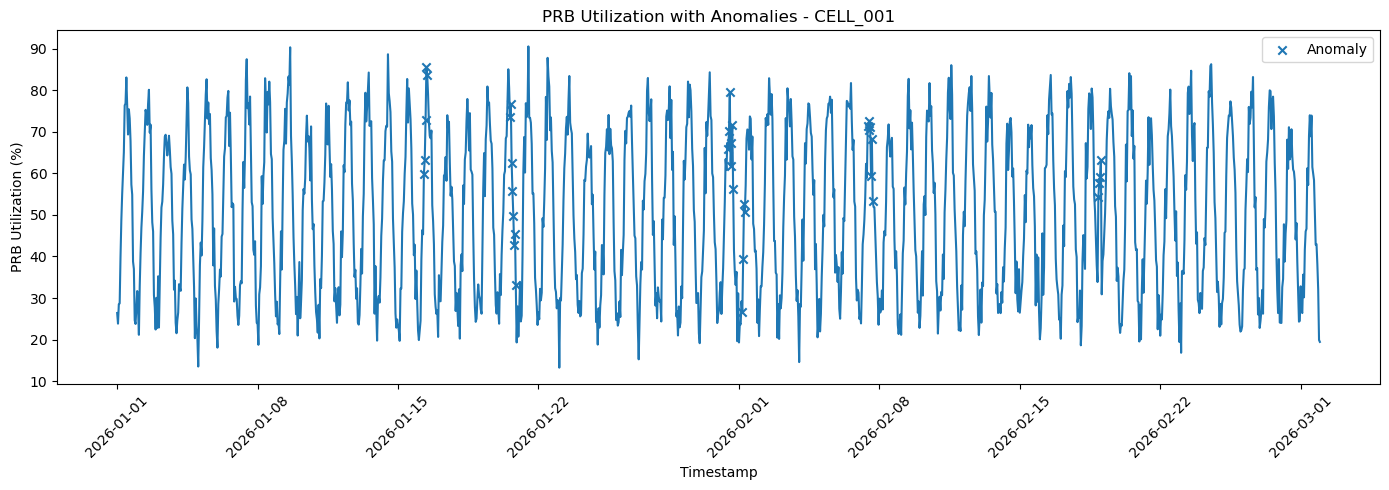

In [16]:
# Quick visualization for one cell

sample_cell = "CELL_001"
plot_df = kpi_df[kpi_df["cell_id"] == sample_cell].copy()

plt.figure(figsize=(14, 5))
plt.plot(plot_df["timestamp"], plot_df["prb_utilization"])
plt.scatter(
    plot_df.loc[plot_df["anomaly_label"] == 1, "timestamp"],
    plot_df.loc[plot_df["anomaly_label"] == 1, "prb_utilization"],
    marker="x",
    label="Anomaly"
)
plt.title(f"PRB Utilization with Anomalies - {sample_cell}")
plt.xlabel("Timestamp")
plt.ylabel("PRB Utilization (%)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

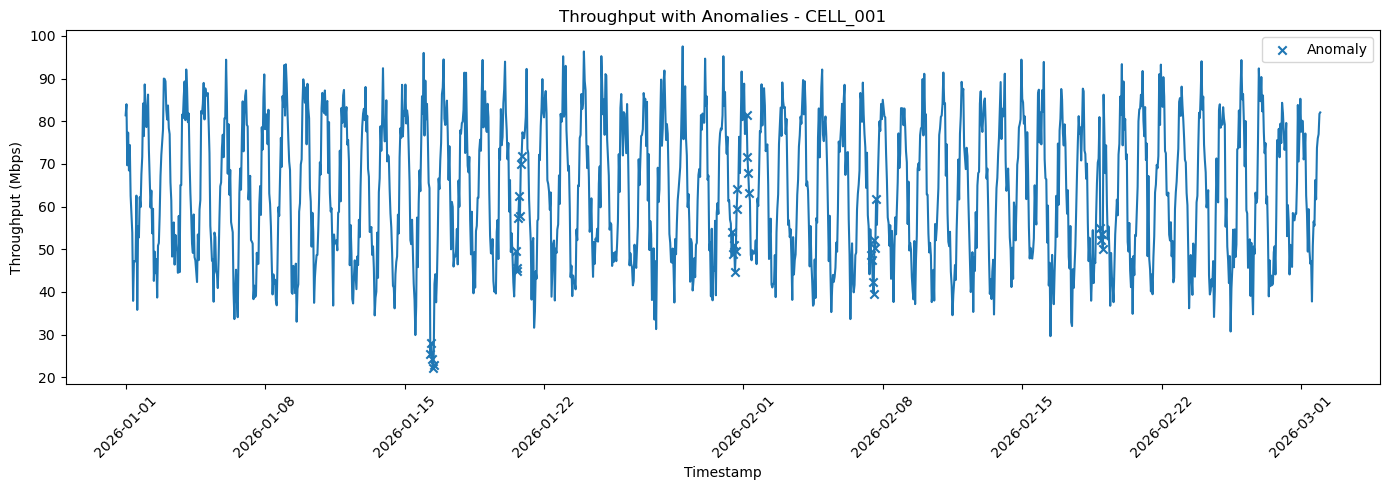

In [18]:
# Another visualization: throughput

plt.figure(figsize=(14, 5))
plt.plot(plot_df["timestamp"], plot_df["throughput_mbps"])
plt.scatter(
    plot_df.loc[plot_df["anomaly_label"] == 1, "timestamp"],
    plot_df.loc[plot_df["anomaly_label"] == 1, "throughput_mbps"],
    marker="x",
    label="Anomaly"
)
plt.title(f"Throughput with Anomalies - {sample_cell}")
plt.xlabel("Timestamp")
plt.ylabel("Throughput (Mbps)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()